<a href="https://colab.research.google.com/github/LFRMontreuil67/website-flow/blob/main/03_Plotly_Express_Interactive_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Execute the code below

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
link = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/weather2019.csv"
df_weather = pd.read_csv(link)

## You have now a DataFrame with lots of weather data

In [ ]:
df_weather.describe()
df_weather.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C,TEMPERATURE_NOON_C,TEMPERATURE_EVENING_C,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WINDTEMP_MAX_C,WEATHER_CODE_MORNING,WEATHER_CODE_NOON,WEATHER_CODE_EVENING,TOTAL_SNOW_MM,UV_INDEX,SUNHOUR,OPINION,MONTH,DAY
0,2019-01-01,9,4,10,4,7,8,0.2,94,9.0,...,3,116,143,176,0,1,5.1,very bad,1,1
1,2019-01-02,8,5,18,7,7,5,0.0,90,9.0,...,3,119,116,116,0,1,8.7,very bad,1,2
2,2019-01-03,6,0,18,0,4,3,0.0,88,10.0,...,-4,116,116,116,0,1,8.7,very bad,1,3
3,2019-01-04,5,-1,15,-1,4,3,0.0,91,10.0,...,-4,116,116,122,0,1,5.1,very bad,1,4
4,2019-01-05,6,-1,8,-1,4,3,0.0,91,8.0,...,-2,143,116,116,0,1,8.7,very bad,1,5


# Now, complete the following tasks :
# Let's go for the show : interactive charts !

## Scatterplot - Add color, title and legend
Need some help ? Go [there for colors](https://plotly.com/python/discrete-color/#directly-mapping-colors-to-data-values) or[ there for labels](https://plotly.com/python/text-and-annotations/)

Maybe [this example](https://plotly.com/python/line-and-scatter/#set-size-and-color-with-column-names) is a good one.

In [ ]:
# Let's draw a simple scatterplot. You know scatterplot, you did a lot with Matplotlib and Seaborn.
# Yes, but here, it's interactive scatterplot.
# Try to draw a rectangle to zoom on the chart, move your mouse over the chart to display values, it's pretty impressive !

fig = px.scatter(data_frame = df_weather,
                 x= "DATE",
                 y="MAX_TEMPERATURE_C",
                 hover_name='DATE')

fig.show() # This time, it's no more plt.show(), we're well on Plotly

# Now, you have to add different colors by Opinion, add a main center title, axis title,
# and change the color with readable values (green when the opinions are pretty good, et red otherwise)

fig = px.scatter(data_frame = df_weather,
                 x= "DATE",
                 y="MAX_TEMPERATURE_C",
                 hover_name='DATE',
                 color="TEMPERATURE_MORNING_C",
                 title="DATE MAX_TEMPERATURE_C"
                 )
fig.show()

## Pair Plots

With Plotly, the name of [pairplots](https://plotly.com/python/splom/) is `scatter_matrix`.

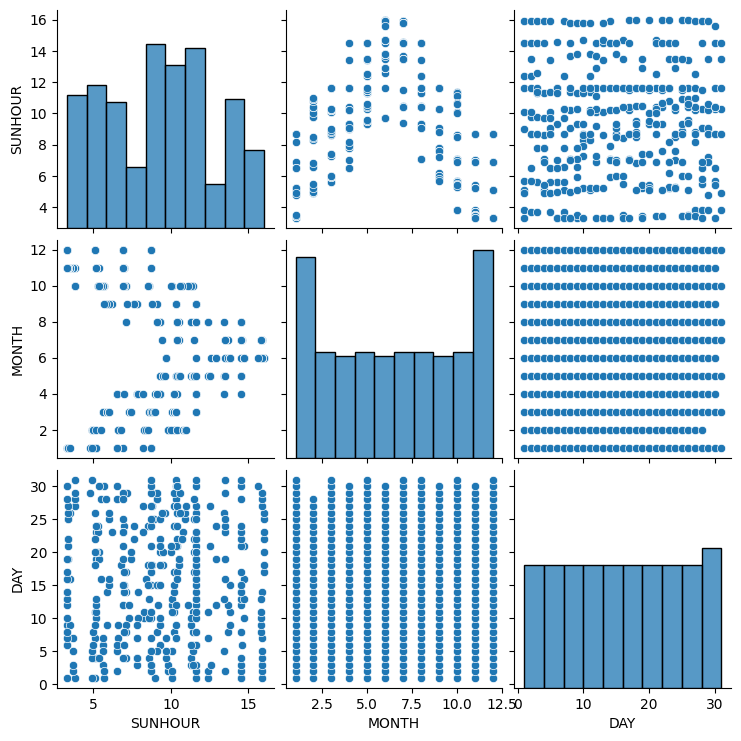

In [ ]:
# OK, it's up to you to draw a Pair Plot on the 4 last columns of your DataFrame.
# Do you notice that qualitative values are correctly represented ?
import seaborn as sns
"""
df1 = df_weather[df_weather.columns[-2:]]
sns.pairplot(df1)

df2 = df_weather[df_weather.columns[-4:-2]]
sns.pairplot(df2)
"""
df2 = df_weather[df_weather.columns[-4:]]
sns.pairplot(df2)

fig.show()


## Bubble chart

[Documentation](https://plotly.com/python/bubble-charts/#bubble-chart-with-plotlyexpress)

In [ ]:
# A bubble chart is a scatter plot with different sizes of dots.
# You know how to do scatterplot ? So maybe you can search a "size" argument...
# Now, draw a bubble chart with Date on X-axis, Max Temperature on Y-axis, and Precipitation (rain quantity) for the size.
# Don't forget to add title and axis title.

# which period is the rainiest ?
import plotly.express as px

fig = px.scatter(
    data_frame=df_weather,
    x="DATE",
    y="MAX_TEMPERATURE_C",
    size="PRECIP_TOTAL_DAY_MM",  # Size of bubbles based on precipitation
    title="Bubble Chart: Max Temperature vs. Date (Size = Precipitation)",
    labels={
        "DATE": "Date",
        "MAX_TEMPERATURE_C": "Max Temperature (°C)",
        "PRECIP_TOTAL_DAY_MM": "Precipitation (mm)"
    },
    hover_name="DATE",  # Show date on hover
    size_max=20  # Adjust the maximum size of the bubbles
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Max Temperature (°C)"
)

fig.show()



## Figure with multi-charts

In [ ]:
# Draw a scatterplot with Max Temperature on Y-axis, and Precipitation on X-axis.
# Not really "one" scatterplot, but 5 charts on columns, one by opinion. Maybe with the "facet_col" argument ?

# Could you add an hover name (when you overview with the mouse) with the Month ?
fig = px.scatter(
    df_weather,
    x="PRECIP_TOTAL_DAY_MM",
    y="MAX_TEMPERATURE_C",
    facet_col="OPINION",   # crée les 5 colonnes
    hover_name="MONTH"     # texte affiché au survol
)

fig.show()

## Draw 5 violin charts on the same figure
Do you know box plot ? Violin is like a box plot, but with density.

In [ ]:
# Complete the code below to add Opinion on color argument.
# Change colors to be coherent and not to draw a rainbow.
# Could you read on the graph which is the max temperature for a "bad" weather ?


fig = px.violin(
    df_weather,
    y="MAX_TEMPERATURE_C",
    color="OPINION",  # ✅ ajout de la couleur
    box=True,
    points="all",
    color_discrete_map={  # ✅ couleurs cohérentes
        "bad": "#d62728",     # rouge
        "average": "#7f7f7f", # gris
        "good": "#2ca02c"     # vert
    }
)
fig.show()

## 3D Chart
Do you have some 3D glasses ?

In [ ]:
# Draw a 3D Scatterplot with Max Temperature on X-axis, Windspeed on Y-axis and Month on Z-axis

fig = px.scatter_3d(
    df_weather,
    x="MAX_TEMPERATURE_C",
    y="WINDSPEED_MAX_KMH",
    z="MONTH",
    color="OPINION"  # optionnel mais utile pour lire
)
fig.show()
# OK, you can move the cube with your mouse, that's impressive. But it's not readable, let's try another thing with the same data.

## 3D Chart are impressive, but not readable, let's try another thing with the same data.
## Dynamic chart !

Tip : You can force the scale of an axis with update axes. For example, to have a X-axis between 0 and 20, you should use :
`fig.update_xaxes(range=[0, 20])`.
And of course, it's is the same for Y-axis with `update_yaxes`.

In [ ]:
# Draw a scatterplot with Max Temperature on X-axis, Windspeed on Y-axis (same as previously), and Month on animation_frame argument.

fig = px.scatter(
    df_weather,
    x="MAX_TEMPERATURE_C",
    y="WINDSPEED_MAX_KMH",
    animation_frame="MONTH",
    color="OPINION"  # optionnel mais recommandé
)

# ✅ Fix des axes pour éviter que ça bouge
fig.update_layout(
    xaxis=dict(range=[df_weather["MAX_TEMPERATURE_C"].min(), df_weather["MAX_TEMPERATURE_C"].max()]),
    yaxis=dict(range=[df_weather["WINDSPEED_MAX_KMH"].min(), df_weather["WINDSPEED_MAX_KMH"].max()])
)

fig.show()


# You can push the play button below. That's cool, it's dynamic and readable !
# But... hey ! My dots are going away outside of my chart ! You have to catch them ! (or maybe just change the default value of the scale axis range)





## Another dynamic colored (and more useful) chart
Draw a **barchart** with Day for X-axis and Month for animation.

Choose you prefered variables for Y-axis, and color.

You can use `range_x=[0,31]` to be sure your X-axis will be always the same.

Of course, don't forget to add title, legend, etc...


In [ ]:
# Your code here :
fig = px.bar(
    df_weather,
    x="DAY",
    y="MAX_TEMPERATURE_C",
    color="OPINION",
    animation_frame="MONTH",
    range_x=[0, 31],  # fixe l’axe X
    title="Daily Max Temperature by Month",
    labels={
        "DAY": "Day of Month",
        "MAX_TEMPERATURE_C": "Max Temperature (°C)",
        "OPINION": "Weather Opinion"
    }
)

fig.update_layout(
    yaxis_title="Max Temperature (°C)",
    legend_title="Weather Type"
)

fig.show()

# Export
You just have to execute the code below to download your HTML page. Congratulations ! That's a first step for your data portfolio !

For your information, Plotly export D3.js document embedded in an HTML page. D3.js is JavaScript library. You don't need to know JavaScript to export from Plotly. But, if you are insterested, you [can go here](https://d3js.org/).

In [ ]:
# Export en page web edimensionnabla D3JS
from plotly.offline import plot
plot(fig)

from google.colab import files
files.download('temp-plot.html')

